In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import os
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

In [2]:
from _utils._utils_spline import eval_spline_basis_equispaced_numeric
from _utils._utils_models import builder_dict

Failed Data


In [3]:
data = pickle.load(open(os.path.join("../data", "data12345newf1.pkl"), "rb"))

In [4]:
replication = 0
key = ('f1', 0.5)
x, y = data[key][replication]
x_order = np.argsort(x)
x, y = x[x_order], y[x_order]

In [24]:
degree = 3
x_vals = x.copy()
x_plot = np.linspace(np.min(x_vals), np.max(x_vals), 500)
num_knots = 5
a = 1.0
b = 0.1

In [76]:
implementation = 'centring+dropping'
builder = 'ortho_diag'
model, X, X_plot, var_names = builder_dict[builder](x, y, a, b, degree, num_knots, implementation, penalised=False, order=2)
X, X_plot = X - np.mean(X, axis=0), X_plot - np.mean(X, axis=0)

In [78]:
implementation = 'svd'
builder = 'ortho_diag'
model, X_, X_plot_, var_names = builder_dict[builder](x, y, a, b, degree, num_knots, implementation, penalised=False, order=2)
X_, X_plot_ = X_ - np.mean(X_, axis=0), X_plot_ - np.mean(X_, axis=0)

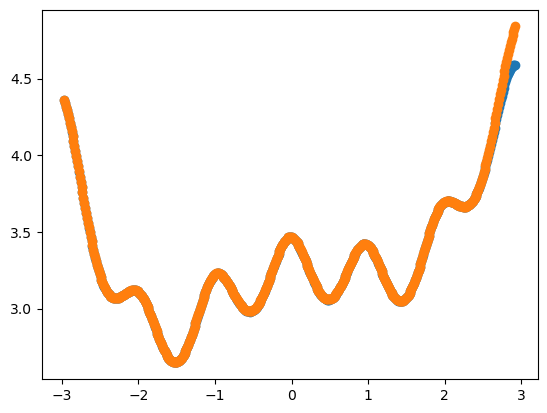

In [80]:
plt.scatter(x_plot, np.diag(X_plot@X_plot.T)*10)
# plt.scatter(x, np.diag(X@X.T))

plt.scatter(x_plot, np.diag(X_plot_@X_plot_.T)*10)
# plt.scatter(x, np.diag(X_@X_.T))
plt.show()

In [44]:
B = eval_spline_basis_equispaced_numeric(degree, np.min(x_vals), np.max(x_vals), num_knots, x_vals)['B']
X_plot = eval_spline_basis_equispaced_numeric(degree, np.min(x_vals), np.max(x_vals), num_knots, x_plot)['B']
X_plot = X_plot - np.mean(X_plot, axis=0)
n, k = B.shape